C:\Users\hamza\AppData\Local\Temp\ipykernel_56060\1665617972.py:123: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) DejaVu Sans.
  plt.savefig('C:/Users/hamza/OneDrive/Desktop/bank-churn-project/dashboard/churn_dashboard.png', dpi=150,
c:\Users\hamza\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127974 (\N{BANK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


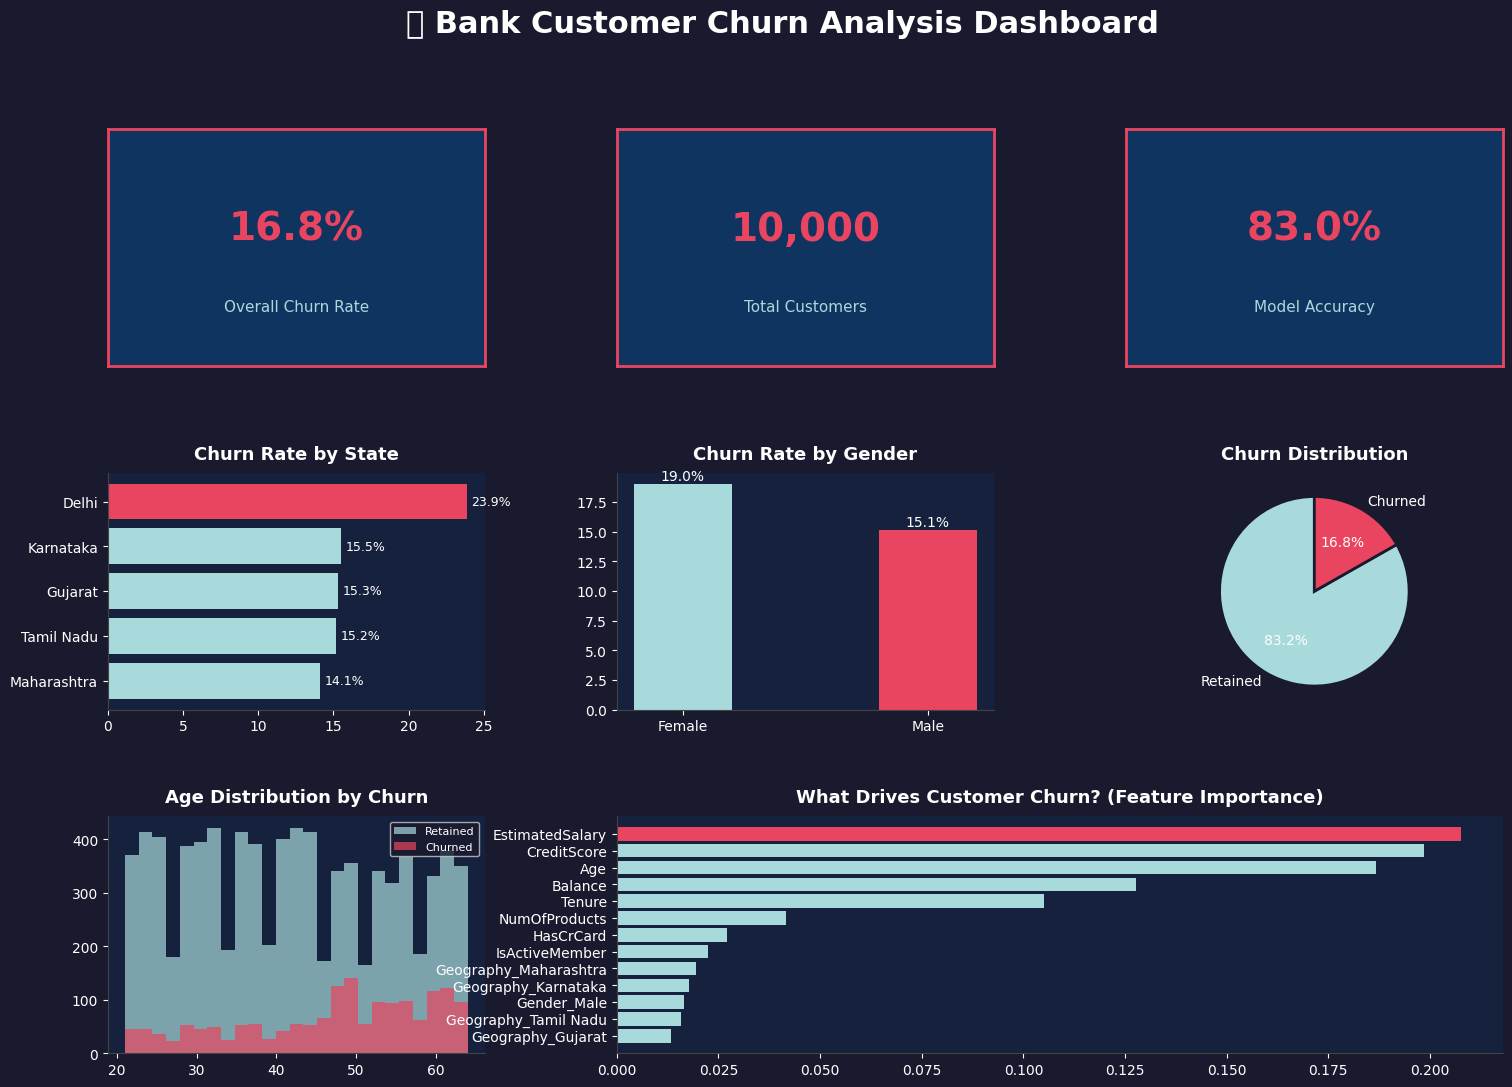

✅ Dashboard saved to dashboard/churn_dashboard.png!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv('C:/Users/hamza/OneDrive/Desktop/bank-churn-project/data/Churn_Modelling.csv')

# Prepare model data
df_model = df.drop(['RowNumber','CustomerId','Surname','FirstName'], axis=1)
df_model = pd.get_dummies(df_model, columns=['Geography','Gender'], drop_first=True)
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test) * 100
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

# ── Dashboard Layout ──────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#1A1A2E')
fig.suptitle('🏦 Bank Customer Churn Analysis Dashboard',
             fontsize=22, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

title_style = dict(fontsize=13, fontweight='bold', color='white', pad=10)
bg = '#16213E'
accent = '#0F3460'

# ── KPI Cards (top row) ───────────────────────────
kpis = [
    (f"{df['Exited'].mean()*100:.1f}%", "Overall Churn Rate"),
    (f"{len(df):,}", "Total Customers"),
    (f"{accuracy:.1f}%", "Model Accuracy"),
]
for i, (val, label) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(accent)
    ax.text(0.5, 0.58, val, ha='center', va='center',
            fontsize=28, fontweight='bold', color='#E94560', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=11, color='#A8DADC', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#E94560')
        spine.set_linewidth(2)

# ── Churn by State ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(bg)
state = df.groupby('Geography')['Exited'].mean().mul(100).sort_values()
colors = ['#A8DADC' if v < 20 else '#E94560' for v in state.values]
bars = ax2.barh(state.index, state.values, color=colors, edgecolor='none')
for bar, val in zip(bars, state.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', color='white', fontsize=9)
ax2.set_title('Churn Rate by State', **title_style)
ax2.tick_params(colors='white')
ax2.set_facecolor(bg)
ax2.spines['bottom'].set_color('#444')
ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.label.set_color('white')

# ── Churn by Gender ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(bg)
gender = df.groupby('Gender')['Exited'].mean().mul(100)
ax3.bar(gender.index, gender.values, color=['#A8DADC','#E94560'], width=0.4)
for i, val in enumerate(gender.values):
    ax3.text(i, val + 0.3, f'{val:.1f}%', ha='center', color='white', fontsize=10)
ax3.set_title('Churn Rate by Gender', **title_style)
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Churn Distribution Donut ──────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(bg)
sizes = df['Exited'].value_counts()
ax4.pie(sizes, labels=['Retained','Churned'],
        colors=['#A8DADC','#E94560'],
        autopct='%1.1f%%', startangle=90,
        textprops={'color':'white', 'fontsize':10},
        wedgeprops={'edgecolor':'#1A1A2E', 'linewidth':2})
ax4.set_title('Churn Distribution', **title_style)

# ── Age Distribution ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor(bg)
ax5.hist(df[df['Exited']==0]['Age'], bins=25, alpha=0.7, color='#A8DADC', label='Retained')
ax5.hist(df[df['Exited']==1]['Age'], bins=25, alpha=0.7, color='#E94560', label='Churned')
ax5.set_title('Age Distribution by Churn', **title_style)
ax5.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=8)
ax5.tick_params(colors='white')
ax5.spines['bottom'].set_color('#444')
ax5.spines['left'].set_color('#444')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# ── Feature Importance ────────────────────────────
ax6 = fig.add_subplot(gs[2, 1:])
ax6.set_facecolor(bg)
colors_imp = ['#E94560' if v == importances.max() else '#A8DADC' for v in importances.values]
ax6.barh(importances.index, importances.values, color=colors_imp)
ax6.set_title('What Drives Customer Churn? (Feature Importance)', **title_style)
ax6.tick_params(colors='white')
ax6.spines['bottom'].set_color('#444')
ax6.spines['left'].set_color('#444')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# ── Save ──────────────────────────────────────────
plt.savefig('C:/Users/hamza/OneDrive/Desktop/bank-churn-project/dashboard/churn_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#1A1A2E')
plt.show()
print("✅ Dashboard saved to dashboard/churn_dashboard.png!")